In [1]:
%pip install azure-ai-vision-imageanalysis matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.ai.vision.imageanalysis.models import VisualFeatures
from azure.core.credentials import AzureKeyCredential

In [ ]:
# Clean the strings
key = "<REDACTED_API_KEY>"
endpoint = "https://temp-east-azure-ai.cognitiveservices.azure.com/"

In [10]:
# 1. FORCE CLEAN THE STRINGS (Ensures no hidden spaces or tabs)
clean_key = key.strip()
clean_endpoint = endpoint.strip().rstrip("/")
print(f"Connecting to: {clean_endpoint}...")

Connecting to: https://temp-east-azure-ai.cognitiveservices.azure.com...


In [11]:
client = ImageAnalysisClient(
    endpoint=clean_endpoint, 
    credential=AzureKeyCredential(clean_key)
)

## Loading Data for Image Analysis

In [12]:
import os
from PIL import Image

image_folder = "rush_album_covers"
album_covers = []

for filename in os.listdir(image_folder):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        path = os.path.join(image_folder, filename)
        with open(path, "rb") as f:
            album_covers.append({"id": filename, "data": f.read(), "path": path})

print(f"Loaded {len(album_covers)} album covers.")

Loaded 6 album covers.


## Image Captioning

Generating caption for AFarewellToKings.png...
--- AFarewellToKings.png ---
Caption: 'a man sitting in a chair in front of a destroyed building'
Confidence: 78.91%


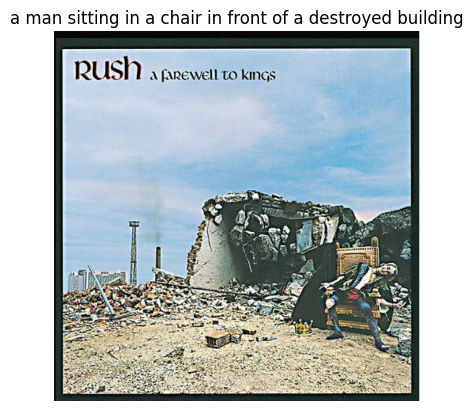

In [13]:
# Analyze the first album cover
target_album = album_covers[0]

print(f"Generating caption for {target_album['id']}...")

result = client.analyze(
    image_data=target_album['data'],
    visual_features=[VisualFeatures.CAPTION],
    gender_neutral_caption=False  # Set to True for gender-neutral terms
)

if result.caption is not None:
    print(f"--- {target_album['id']} ---")
    print(f"Caption: '{result.caption.text}'")
    print(f"Confidence: {result.caption.confidence * 100:.2f}%")
    
    # Display the image
    img = Image.open(target_album['path'])
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis("off")
    plt.title(result.caption.text)
    plt.show()

## Dense Captioning

In [14]:
print(f"Generating dense captions for {target_album['id']}...")

dense_result = client.analyze(
    image_data=target_album['data'],
    visual_features=[VisualFeatures.DENSE_CAPTIONS]
)

print(f"--- Dense Captions for {target_album['id']} ---")
for i, caption in enumerate(dense_result.dense_captions.list):
    print(f"{i+1}. '{caption.text}' (Confidence: {caption.confidence * 100:.2f}%)")

Generating dense captions for AFarewellToKings.png...
--- Dense Captions for AFarewellToKings.png ---
1. 'a man sitting in a chair in front of a destroyed building' (Confidence: 78.91%)
2. 'a man sitting on a chair' (Confidence: 81.84%)
3. 'a close-up of a destroyed building' (Confidence: 71.43%)


## Analyzing Multiple Images

In [15]:
for album in album_covers:
    print(f"Processing {album['id']}...")
    res = client.analyze(image_data=album['data'], visual_features=[VisualFeatures.CAPTION])
    if res.caption:
        print(f"Result: {res.caption.text}")
    print("-" * 30)

Processing AFarewellToKings.png...
Result: a man sitting in a chair in front of a destroyed building
------------------------------
Processing MovingPictures.png...
Result: a group of people in red uniforms holding framed pictures
------------------------------
Processing PermanentWaves.png...
Result: a woman walking on a beach
------------------------------
Processing RollTheBones.png...
Result: a boy kicking a skull
------------------------------
Processing Signals.png...
Result: a dog sniffing a red fire hydrant
------------------------------
Processing TestForEcho.png...
Result: a rock stack in the snow
------------------------------
